   feature_1  feature_2  feature_3    target
0   0.000000   1.000000   0.049671  0.268485
1   0.100166   0.998742  -0.008810  0.319935
2   0.199325   0.994971   0.074802  0.450479
3   0.296479   0.988696   0.167353  0.508837
4   0.390650   0.979933  -0.003348  0.487590


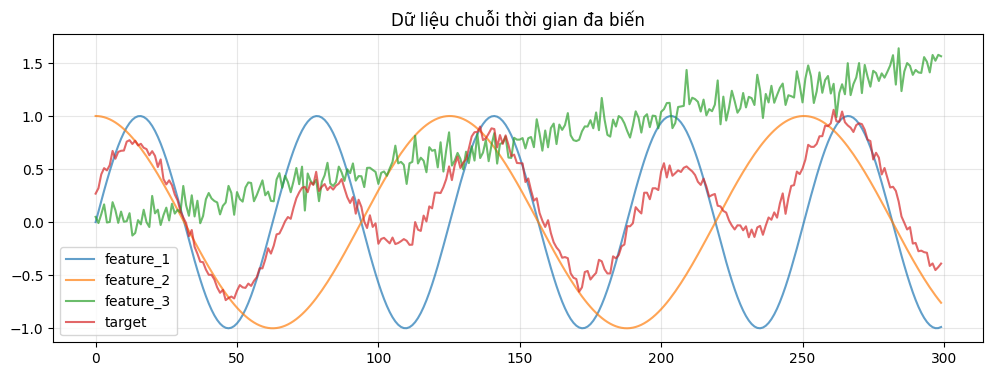

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

time_steps = 300
t = np.linspace(0, 30, time_steps)
feature_1 = np.sin(t)
feature_2 = np.cos(0.5 * t)
feature_3 = 0.05 * t + 0.1 * np.random.randn(time_steps)
target = 0.5 * feature_1 + 0.3 * feature_2 + 0.2 * feature_3 + 0.05 * np.random.randn(time_steps)

df = pd.DataFrame({
    'feature_1': feature_1,
    'feature_2': feature_2,
    'feature_3': feature_3,
    'target': target,
})
print(df.head())

plt.figure(figsize=(12, 4))
for col in df.columns:
    plt.plot(df[col], label=col, alpha=0.7)
plt.legend(); plt.grid(alpha=0.3)
plt.title('Dữ liệu chuỗi thời gian đa biến')
plt.show()


In [2]:
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)

train_df = df[:train_size]

val_df = df[
    train_size : train_size + val_size
]

test_df = df[
    train_size + val_size :
]

print("Train size:", len(train_df))
print("Validation size:", len(val_df))
print("Test size:", len(test_df))

Train size: 210
Validation size: 45
Test size: 45


In [7]:
from sklearn.preprocessing import MinMaxScaler

# Tạo scaler
scaler = MinMaxScaler()

# Fit trên train
scaler.fit(train_df)

# Transform dữ liệu
train_scaled = scaler.transform(train_df)
val_scaled = scaler.transform(val_df)
test_scaled = scaler.transform(test_df)

In [8]:
seq_length = 20

In [9]:
seq_length = 20

def create_sequences(data, seq_length):

    X = []
    y = []

    for i in range(len(data) - seq_length):

        # Lấy 20 bước thời gian
        X.append(
            data[i:i + seq_length, :-1]
        )

        # Target tại bước tiếp theo
        y.append(
            data[i + seq_length, -1]
        )

    return np.array(X), np.array(y)

In [10]:
X_train, y_train = create_sequences(
    train_scaled,
    seq_length
)

X_val, y_val = create_sequences(
    val_scaled,
    seq_length
)

X_test, y_test = create_sequences(
    test_scaled,
    seq_length
)

In [11]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (190, 20, 3)
y_train shape: (190,)
X_val shape: (25, 20, 3)
y_val shape: (25,)
X_test shape: (25, 20, 3)
y_test shape: (25,)


torch.Size([190, 20, 3])
torch.Size([190])
RNNModel(
  (rnn): RNN(3, 32, batch_first=True)
  (fc): Linear(in_features=32, out_features=1, bias=True)
)
Epoch [10/150] Train Loss: 0.268992 Val Loss: 0.238453
Epoch [20/150] Train Loss: 0.059299 Val Loss: 0.028505
Epoch [30/150] Train Loss: 0.062867 Val Loss: 0.029104
Epoch [40/150] Train Loss: 0.043111 Val Loss: 0.026028
Epoch [50/150] Train Loss: 0.037459 Val Loss: 0.021359
Epoch [60/150] Train Loss: 0.031337 Val Loss: 0.016143
Epoch [70/150] Train Loss: 0.025318 Val Loss: 0.015180
Epoch [80/150] Train Loss: 0.020013 Val Loss: 0.013420
Epoch [90/150] Train Loss: 0.014768 Val Loss: 0.010543
Epoch [100/150] Train Loss: 0.010188 Val Loss: 0.009946
Epoch [110/150] Train Loss: 0.006963 Val Loss: 0.008377
Epoch [120/150] Train Loss: 0.005462 Val Loss: 0.008335
Epoch [130/150] Train Loss: 0.004819 Val Loss: 0.006917
Epoch [140/150] Train Loss: 0.004251 Val Loss: 0.005421
Epoch [150/150] Train Loss: 0.003813 Val Loss: 0.004286


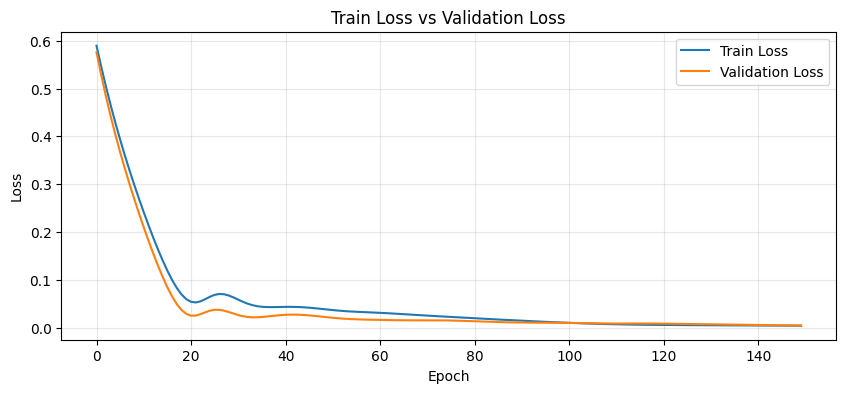

Test Loss: 0.004815350286662579


In [12]:
import torch
import torch.nn as nn

X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.FloatTensor(y_train)

X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.FloatTensor(y_val)

X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.FloatTensor(y_test)

print(X_train_tensor.shape)
print(y_train_tensor.shape)

#xay dung mo hinh RNN
class RNNModel(nn.Module):

    def __init__(self, input_size, hidden_size, output_size):

        super(RNNModel, self).__init__()

        self.hidden_size = hidden_size

        self.rnn = nn.RNN(
            input_size=input_size,
            hidden_size=hidden_size,
            batch_first=True
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):

        # output shape:
        # (batch_size, seq_length, hidden_size)

        out, hidden = self.rnn(x)

        # Lấy output tại timestep cuối
        out = out[:, -1, :]

        # Fully Connected
        out = self.fc(out)

        return out

#Khoi tao mo hinh

input_size = 3
hidden_size = 32
output_size = 1

model = RNNModel(
    input_size,
    hidden_size,
    output_size
)

print(model)

#Loss function và Optimizer

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)


#Huan luyen mo hinh

epochs = 150

train_losses = []
val_losses = []

for epoch in range(epochs):

    # ===== TRAIN =====
    model.train()

    optimizer.zero_grad()

    outputs = model(X_train_tensor)

    loss = criterion(
        outputs.squeeze(),
        y_train_tensor
    )

    loss.backward()

    optimizer.step()

    # ===== VALIDATION =====
    model.eval()

    with torch.no_grad():

        val_outputs = model(X_val_tensor)

        val_loss = criterion(
            val_outputs.squeeze(),
            y_val_tensor
        )

    # Lưu loss
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    # In kết quả
    if (epoch + 1) % 10 == 0:

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {loss.item():.6f} "
            f"Val Loss: {val_loss.item():.6f}"
        )


#ve bieu do loss

plt.figure(figsize=(10, 4))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.title('Train Loss vs Validation Loss')

plt.legend()
plt.grid(alpha=0.3)

plt.show()


#kiem tra du doan test

model.eval()

with torch.no_grad():

    test_predictions = model(X_test_tensor)

    test_loss = criterion(
        test_predictions.squeeze(),
        y_test_tensor
    )

print("Test Loss:", test_loss.item())

RNN Test MSE: 0.004815349821001291
RNN Test MAE: 0.06186695024371147
Naive MSE: 0.002593421449518633
Naive MAE: 0.04040721628079717
===== So sánh =====
RNN   -> MSE: 0.004815 | MAE: 0.061867
Naive -> MSE: 0.002593 | MAE: 0.040407


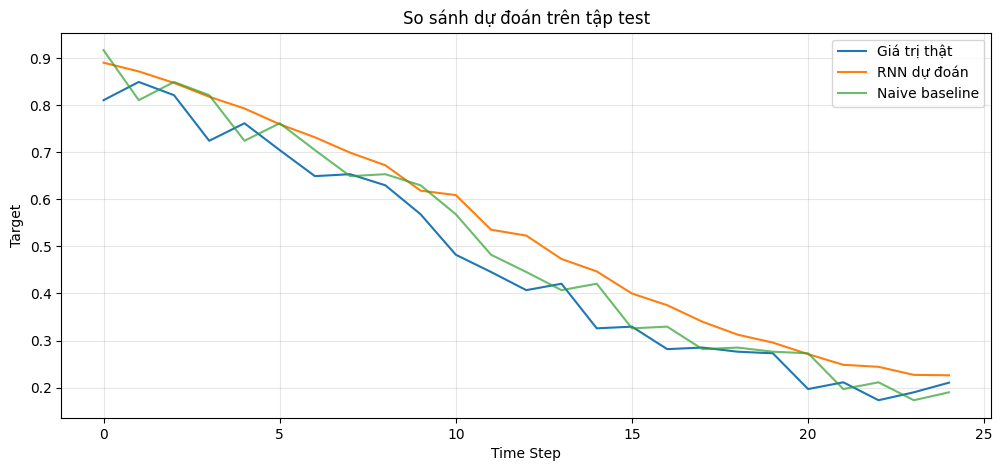

In [15]:
#thu vien
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

#du doan tren tap test
model.eval()

with torch.no_grad():

    predictions = model(X_test_tensor)

predictions = predictions.squeeze().numpy()
y_true = y_test_tensor.numpy()



#Tính MSE và MAE
mse = mean_squared_error(
    y_true,
    predictions
)

mae = mean_absolute_error(
    y_true,
    predictions
)

print("RNN Test MSE:", mse)
print("RNN Test MAE:", mae)


#Tạo naive prediction
# Lấy giá trị cuối cùng của target trong sequence

naive_predictions = []

for i in range(len(test_scaled) - seq_length):

    naive_pred = test_scaled[
        i + seq_length - 1,
        -1
    ]

    naive_predictions.append(naive_pred)

naive_predictions = np.array(naive_predictions)


#Đánh giá baseline
naive_mse = mean_squared_error(
    y_true,
    naive_predictions
)

naive_mae = mean_absolute_error(
    y_true,
    naive_predictions
)

print("Naive MSE:", naive_mse)
print("Naive MAE:", naive_mae)

#So sanh ket qua
print("===== So sánh =====")

print(f"RNN   -> MSE: {mse:.6f} | MAE: {mae:.6f}")

print(f"Naive -> MSE: {naive_mse:.6f} | MAE: {naive_mae:.6f}")

#ve bieu do du doan
plt.figure(figsize=(12, 5))

plt.plot(
    y_true,
    label='Giá trị thật'
)

plt.plot(
    predictions,
    label='RNN dự đoán'
)

plt.plot(
    naive_predictions,
    label='Naive baseline',
    alpha=0.7
)

plt.title('So sánh dự đoán trên tập test')

plt.xlabel('Time Step')
plt.ylabel('Target')

plt.legend()
plt.grid(alpha=0.3)

plt.show()